In [1]:
# =========================================================
# BANGLAROAD
# ResNet18 RCNN STYLE
# CLASSIFICATION + BBOX REGRESSION + GRAD-CAM
# =========================================================

In [2]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
# =========================================================
# 2. SOROKH-POTH DATASET PATHS
# =========================================================

DATASET_INFO = {

    "BiCycle": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/BiCycle_Image-20230408T174520Z-001/BiCycle_Image",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/BiCycle_Annotations-20230408T151922Z-001/BiCycle_Annotations"
    },

    "Bike": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Bike_Image-20230408T175508Z-001/Bike_Image",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Bike_Annotations-20230408T175502Z-001/Bike_Annotations"
    },

    "Bus": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Bus_Image-20230408T175800Z-001/Bus_Image",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Bus_Annotations-20230408T175758Z-001/Bus_Annotations"
    },

    "CNG": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/CNG_Image-20230408T181646Z-001/CNG_Image",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/CNG_Annotations-20230408T181642Z-001/CNG_Annotations"
    },

    "Car": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Car_Image-20230408T181401Z-001/Car_Image",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Car_Annotations-20230408T181357Z-001/Car_Annotations"
    },

    "Leguna": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Leguna_Image-20230408T182004Z-001/Leguna_Image",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Leguna_Annotations-20230408T182000Z-001/Leguna_Annotations"
    },

    "Rickshaw": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Rickshaw_Image-20230408T182344Z-001/Rickshaw_Image",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Rickshaw_Annotations-20230408T182340Z-001/Rickshaw_Annotations"
    },

    "Truck": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Truck_Image-20230408T182357Z-001/Truck_Image",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/Truck_Annotations-20230408T182351Z-001/Truck_Annotations"
    },

    "VAN": {
        "img": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/VAN_Images-20230408T185622Z-001/VAN_Images",
        "ann": "/kaggle/input/datasets/nayemsiddiki/sorokh-pothbd/Sorokh-Poth A Balanced Bangladeshi Road Vehicle Image Dataset/VAN_Annotations-20230408T185628Z-001/VAN_Annotations"
    }
}

In [4]:
# =========================================================
# 3. CONFIGURATION
# =========================================================

NUM_CLASSES = 9
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
CLASS_NAMES = [
    "BiCycle",
    "Bike",
    "Bus",
    "CNG",
    "Car",
    "Leguna",
    "Rickshaw",
    "Truck",
    "VAN"
]

In [5]:
# =========================================================
# 4. DATA AUGMENTATION
# =========================================================

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# =========================================================
# SOROKH-POTH DATASET
# =========================================================

class BanglaRoadDataset(Dataset):

    def __init__(self, dataset_info, transform=None):

        self.transform = transform

        self.samples = []

        class_to_idx = {
            name: idx
            for idx, name in enumerate(dataset_info.keys())
        }

        for class_name, paths in dataset_info.items():

            img_dir = paths["img"]
            ann_dir = paths["ann"]

            class_id = class_to_idx[class_name]

            image_paths = []

            for ext in ['*.jpg', '*.jpeg', '*.png']:

                image_paths.extend(
                    glob.glob(
                        os.path.join(img_dir, ext)
                    )
                )

            for img_path in image_paths:

                filename = os.path.basename(img_path)

                txt_name = os.path.splitext(filename)[0] + ".txt"

                ann_path = os.path.join(
                    ann_dir,
                    txt_name
                )

                self.samples.append(
                    (
                        img_path,
                        ann_path,
                        class_id
                    )
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        image_path, ann_path, class_id = self.samples[idx]

        image = Image.open(image_path).convert("RGB")

        bbox = [0.5, 0.5, 0.5, 0.5]

        if os.path.exists(ann_path):

            with open(ann_path, 'r') as f:

                lines = f.readlines()

            for line in lines:

                values = line.strip().split()

                if len(values) >= 5:

                    try:

                        bbox = [
                            float(values[1]),
                            float(values[2]),
                            float(values[3]),
                            float(values[4])
                        ]

                        break

                    except:
                        pass

        if self.transform:

            image = self.transform(image)

        return (
            image,
            torch.tensor(class_id, dtype=torch.long),
            torch.tensor(bbox, dtype=torch.float32)
        )

In [7]:
# =========================================================
# CREATE FULL DATASET
# =========================================================

full_dataset = BanglaRoadDataset(
    DATASET_INFO,
    transform=train_transform
)

print("Total Images:", len(full_dataset))

# =========================================================
# TRAIN / VALID / TEST SPLIT
# =========================================================

train_size = int(0.7 * len(full_dataset))

valid_size = int(0.15 * len(full_dataset))

test_size = len(full_dataset) - train_size - valid_size

train_dataset, valid_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, valid_size, test_size]
)

# Validation/Test transform correction

valid_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# =========================================================
# DATALOADERS
# =========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Total Images: 4331
Train: 3031
Valid: 649
Test : 651


In [8]:
# =========================================================
# RESNET18 RCNN MODEL
# =========================================================

class ResNet18_RCNN(nn.Module):

    def __init__(self, num_classes=9):

        super(ResNet18_RCNN, self).__init__()

        resnet = models.resnet18(
            weights='IMAGENET1K_V1'
        )

        # Remove final FC layer
        self.backbone = nn.Sequential(
            *list(resnet.children())[:-2]
        )

        # Freeze early layers
        for param in self.backbone.parameters():

            param.requires_grad = False

        # Global Pooling
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Shared FC
        self.shared_fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        # Classification Head
        self.classifier = nn.Linear(
            256,
            num_classes
        )

        # Bounding Box Regression Head
        self.bbox_regressor = nn.Linear(
            256,
            4
        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.pool(x)

        x = self.shared_fc(x)

        class_output = self.classifier(x)

        bbox_output = self.bbox_regressor(x)

        return class_output, bbox_output

In [9]:
# =========================================================
# 8. INITIALIZE MODEL
# =========================================================

model = ResNet18_RCNN(
    NUM_CLASSES
).to(DEVICE)

# =========================================================
# 9. LOSS FUNCTIONS
# =========================================================

classification_loss_fn = nn.CrossEntropyLoss()

bbox_loss_fn = nn.SmoothL1Loss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s] 


In [10]:
# =========================================================
# 10. TRAIN FUNCTION
# =========================================================

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels, bboxes in tqdm(loader):

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        bboxes = bboxes.to(DEVICE)

        optimizer.zero_grad()

        class_outputs, bbox_outputs = model(images)

        classification_loss = classification_loss_fn(
            class_outputs,
            labels
        )

        regression_loss = bbox_loss_fn(
            bbox_outputs,
            bboxes
        )

        total_loss = (
            classification_loss +
            regression_loss
        )

        total_loss.backward()

        optimizer.step()

        running_loss += total_loss.item()

        preds = torch.argmax(
            class_outputs,
            dim=1
        )

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [11]:
# =========================================================
# 10. EVALUATION FUNCTION
# =========================================================

@torch.no_grad()
def evaluate(model, loader, phase=None):

    model.eval()

    running_loss = 0

    all_preds = []
    all_labels = []

    for images, labels, bboxes in loader:

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        bboxes = bboxes.to(DEVICE)

        class_outputs, bbox_outputs = model(images)

        classification_loss = classification_loss_fn(
            class_outputs,
            labels
        )

        regression_loss = bbox_loss_fn(
            bbox_outputs,
            bboxes
        )

        total_loss = (
            classification_loss +
            regression_loss
        )

        running_loss += total_loss.item()

        preds = torch.argmax(
            class_outputs,
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    # =================================================
    # METRICS
    # =================================================

    avg_loss = running_loss / len(loader)

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted',
        zero_division=0
    )

    # =================================================
    # PRINT ONLY IF PHASE IS GIVEN
    # =================================================

    if phase is not None:

        print("\n")
        print("="*60)
        print(f"{phase} RESULTS")
        print("="*60)

        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")

        print("\nClassification Report:\n")

        print(
            classification_report(
                all_labels,
                all_preds,
                labels=list(range(NUM_CLASSES)),
                target_names=CLASS_NAMES,
                zero_division=0
            )
        )

        print("="*60)

    return (
        avg_loss,
        accuracy,
        precision,
        recall,
        f1,
        all_labels,
        all_preds
    )

In [12]:
# =========================================================
# 11. TRAINING LOOP
# =========================================================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    # ---------------- VALIDATION ----------------

    val_loss, val_acc, _, _, _, _, _ = evaluate(
        model,
        valid_loader,
        phase=None
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # =====================================================
    # PRINT ONLY EPOCH SUMMARY
    # =====================================================

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

100%|██████████| 95/95 [04:03<00:00,  2.57s/it]



Epoch 1/20
Train Loss: 2.0890 | Val Loss: 1.7397
Train Acc: 0.2851 | Val Acc: 0.6918


100%|██████████| 95/95 [02:48<00:00,  1.78s/it]



Epoch 2/20
Train Loss: 1.5705 | Val Loss: 1.0863
Train Acc: 0.5665 | Val Acc: 0.7858


100%|██████████| 95/95 [02:43<00:00,  1.72s/it]


...


Epoch 18/20
Train Loss: 0.3053 | Val Loss: 0.2455
Train Acc: 0.9037 | Val Acc: 0.9307


100%|██████████| 95/95 [02:39<00:00,  1.68s/it]



Epoch 19/20
Train Loss: 0.2803 | Val Loss: 0.2471
Train Acc: 0.9093 | Val Acc: 0.9230


100%|██████████| 95/95 [02:38<00:00,  1.67s/it]



Epoch 20/20
Train Loss: 0.2732 | Val Loss: 0.2508
Train Acc: 0.9136 | Val Acc: 0.9168


In [13]:
evaluate(
    model,
    valid_loader,
    phase="VALIDATION"
)



VALIDATION RESULTS
Accuracy : 0.9168
Precision: 0.9213
Recall   : 0.9168
F1 Score : 0.9173

Classification Report:

              precision    recall  f1-score   support

     BiCycle       0.99      0.99      0.99        72
        Bike       0.93      0.93      0.93        70
         Bus       0.86      0.88      0.87        91
         CNG       0.97      0.84      0.90        86
         Car       0.89      0.96      0.93        79
      Leguna       1.00      0.86      0.93        43
    Rickshaw       0.84      0.92      0.88        53
       Truck       0.82      0.92      0.87        76
         VAN       1.00      0.95      0.97        79

    accuracy                           0.92       649
   macro avg       0.92      0.92      0.92       649
weighted avg       0.92      0.92      0.92       649



(0.25079879022779916,
 0.9167950693374423,
 0.9213476687964237,
 0.9167950693374423,
 0.9173385951314552,
 [np.int64(7),
  np.int64(3),
  np.int64(4),
  np.int64(4),
  np.int64(6),
  np.int64(1),
  np.int64(3),
  np.int64(6),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(8),
  np.int64(4),
  np.int64(3),
  np.int64(7),
  np.int64(7),
  np.int64(5),
  np.int64(4),
  np.int64(3),
  np.int64(5),
  np.int64(7),
  np.int64(1),
  np.int64(7),
  np.int64(2),
  np.int64(8),
  np.int64(8),
  np.int64(8),
  np.int64(3),
  np.int64(7),
  np.int64(0),
  np.int64(8),
  np.int64(8),
  np.int64(0),
  np.int64(8),
  np.int64(7),
  np.int64(2),
  np.int64(1),
  np.int64(3),
  np.int64(4),
  np.int64(6),
  np.int64(2),
  np.int64(4),
  np.int64(7),
  np.int64(8),
  np.int64(5),
  np.int64(1),
  np.int64(0),
  np.int64(5),
  np.int64(1),
  np.int64(0),
  np.int64(5),
  np.int64(8),
  np.int64(3),
  np.int64(5),
  np.int64(7),
  np.int64(3),
  np.int64(3),
  np.int64(7),
  np.int6

In [14]:
# =========================================================
# 13. TEST PERFORMANCE
# =========================================================

test_loss, test_acc, test_precision, test_recall, test_f1, y_true, y_pred = evaluate(
    model,
    test_loader,
    phase="TEST"
)



TEST RESULTS
Accuracy : 0.9186
Precision: 0.9200
Recall   : 0.9186
F1 Score : 0.9186

Classification Report:

              precision    recall  f1-score   support

     BiCycle       0.96      1.00      0.98        68
        Bike       0.99      0.94      0.96        86
         Bus       0.84      0.94      0.89        84
         CNG       0.89      0.83      0.86        78
         Car       0.89      0.89      0.89        89
      Leguna       0.98      0.91      0.94        46
    Rickshaw       0.86      0.84      0.85        58
       Truck       0.95      0.93      0.94        80
         VAN       0.95      0.98      0.97        62

    accuracy                           0.92       651
   macro avg       0.92      0.92      0.92       651
weighted avg       0.92      0.92      0.92       651



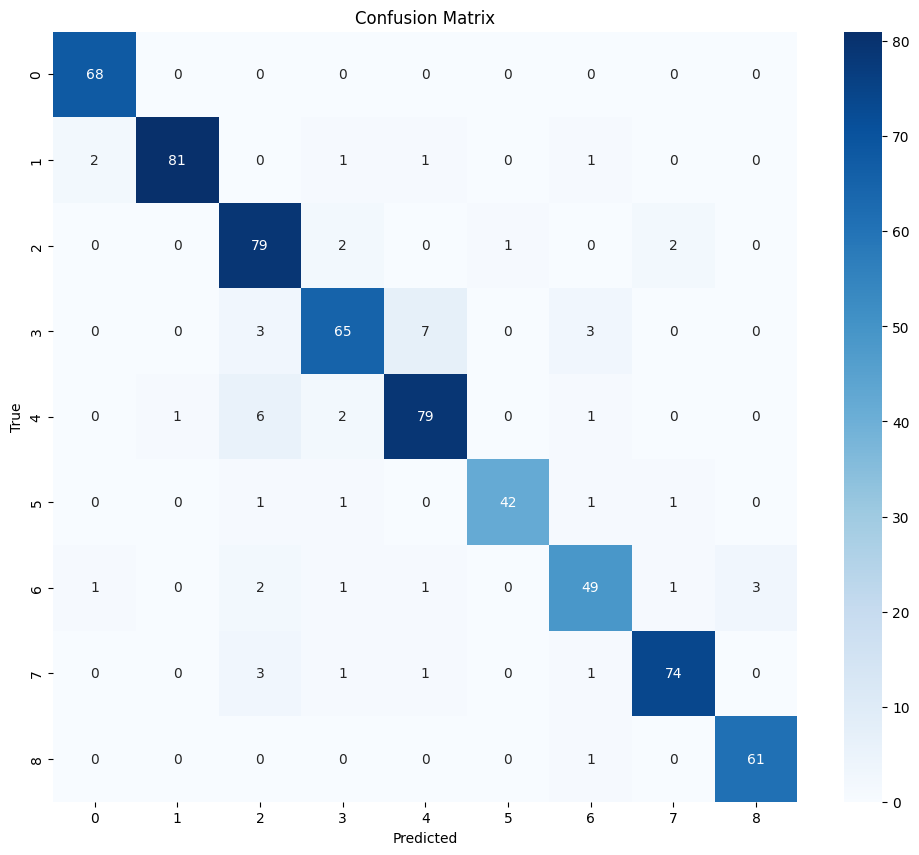

In [15]:
# =========================================================
# 14. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

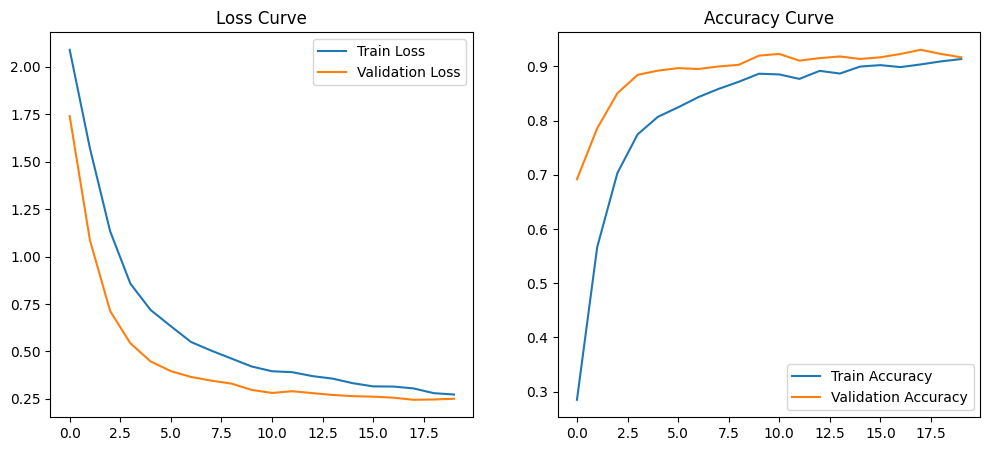

In [16]:
# =========================================================
# 15. TRAINING CURVES
# =========================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.legend()

plt.title("Loss Curve")

plt.subplot(1, 2, 2)

plt.plot(train_accs, label='Train Accuracy')

plt.plot(val_accs, label='Validation Accuracy')

plt.legend()

plt.title("Accuracy Curve")

plt.show()

In [17]:
# =========================================================
# FINAL WORKING GRAD-CAM FOR VGG16
# =========================================================

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model

        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        # Forward hook
        self.forward_handle = self.target_layer.register_forward_hook(
            self.forward_hook
        )

        # Backward hook
        self.backward_handle = self.target_layer.register_full_backward_hook(
            self.backward_hook
        )

    # =====================================================
    # FORWARD HOOK
    # =====================================================

    def forward_hook(self, module, input, output):

        self.activations = output

    # =====================================================
    # BACKWARD HOOK
    # =====================================================

    def backward_hook(self, module, grad_input, grad_output):

        self.gradients = grad_output[0]

    # =====================================================
    # GENERATE CAM
    # =====================================================

    def generate(self, input_tensor, target_class):

        self.gradients = None
        self.activations = None

        self.model.eval()

        # Enable gradient
        input_tensor.requires_grad = True

        class_output, _ = self.model(input_tensor)

        score = class_output[0, target_class]

        self.model.zero_grad()

        score.backward(retain_graph=True)

        # -------------------------------------------------
        # CHECK
        # -------------------------------------------------

        if self.gradients is None:
            raise ValueError("Gradient extraction failed.")

        if self.activations is None:
            raise ValueError("Activation extraction failed.")

        gradients = self.gradients[0]

        activations = self.activations[0]

        # Global Average Pooling
        weights = torch.mean(
            gradients,
            dim=(1, 2)
        )

        cam = torch.zeros(
            activations.shape[1:],
            dtype=torch.float32
        ).to(DEVICE)

        for i, w in enumerate(weights):

            cam += w * activations[i]

        cam = torch.relu(cam)

        cam -= cam.min()

        cam /= (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()

In [18]:
# =========================================================
# 17. INITIALIZE GRAD-CAM
# =========================================================

target_layer = model.backbone[-1]

gradcam = GradCAM(
    model,
    target_layer
)

In [19]:
# =========================================================
# SHOW GRAD-CAM + PREDICTED BBOX
# =========================================================

def show_gradcam(dataset, index=0):

    image_tensor, label, true_bbox = dataset[index]

    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    model.eval()

    with torch.enable_grad():

        class_output, bbox_output = model(input_tensor)

        pred_class = torch.argmax(
            class_output,
            dim=1
        ).item()

        pred_bbox = bbox_output[0].detach().cpu().numpy()

        heatmap = gradcam.generate(
            input_tensor,
            pred_class
        )

    # =====================================================
    # DENORMALIZE IMAGE
    # =====================================================

    image = image_tensor.permute(
        1,
        2,
        0
    ).cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])

    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean

    image = np.clip(image, 0, 1)

    image_uint8 = np.uint8(image * 255)

    # =====================================================
    # PREDICTED BBOX
    # =====================================================

    x_center, y_center, width, height = pred_bbox

    # Convert normalized YOLO -> pixel coordinates

    x_center *= IMAGE_SIZE
    y_center *= IMAGE_SIZE

    width *= IMAGE_SIZE
    height *= IMAGE_SIZE

    x1 = int(x_center - width / 2)
    y1 = int(y_center - height / 2)

    x2 = int(x_center + width / 2)
    y2 = int(y_center + height / 2)

    # Draw predicted bbox

    bbox_image = image_uint8.copy()

    cv2.rectangle(
        bbox_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    cv2.putText(
        bbox_image,
        f"Pred: {pred_class}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

    # =====================================================
    # HEATMAP
    # =====================================================

    heatmap = cv2.resize(
        heatmap,
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    superimposed = cv2.addWeighted(
        image_uint8,
        0.6,
        heatmap,
        0.4,
        0
    )

    # =====================================================
    # PLOT
    # =====================================================

    plt.figure(figsize=(18, 6))

    # -----------------------------------------------------
    # ORIGINAL IMAGE
    # -----------------------------------------------------

    plt.subplot(1, 3, 1)

    plt.imshow(image)

    plt.title("Original Image")

    plt.axis('off')

    # -----------------------------------------------------
    # PREDICTED BBOX
    # -----------------------------------------------------

    plt.subplot(1, 3, 2)

    plt.imshow(
        cv2.cvtColor(
            bbox_image,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Predicted Bounding Box\nClass: {pred_class}"
    )

    plt.axis('off')

    # -----------------------------------------------------
    # GRAD-CAM
    # -----------------------------------------------------

    plt.subplot(1, 3, 3)

    plt.imshow(
        cv2.cvtColor(
            superimposed,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Grad-CAM\nPredicted Class: {pred_class}"
    )

    plt.axis('off')

    plt.show()

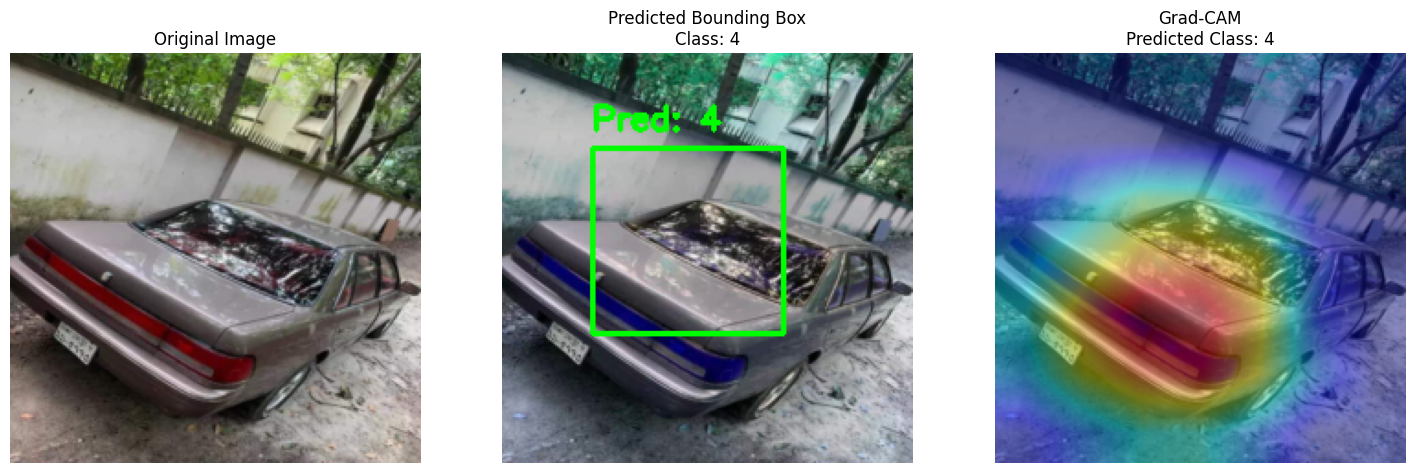

In [20]:
# =========================================================
# 19. RUN GRAD-CAM
# =========================================================

show_gradcam(
    test_dataset,
    index=1
)